#### **Assignment 1: Random Projections**

**Members: Cui(Cathy) Yu, Shravani Mahadeshwar, Priya Botsa, Marc Hayes, Shaonan Feng and Di Yang**

- *Course: Machine Learning 2*
- *Prof: Jan Nagler*
- *Due: 17 April 2026*

#### **Methodology**

In order to complete the assignment we structure the task in seven steps. The first five (1-5) are done for each dataset. In step 6 we compare the results of both datasets to eachother and finally in step 7 we summarize our findings and conclude with our learnings and take-aways.

In this section we provide a brief description of each step:

#### Step 1 - Loading the Datasets

**Dataset 1: COIL-20 (Columbia Object Image Library)**

- `1,440` grayscale images of `20` objects, each photographed from `72` rotation angles (5° intervals)
- Each image is `128x128` pixels, giving **16,384 features** per sample when flattened
- Labels correspond to object identity (20 classes)
- Features normalized to [0, 1] by dividing pixel values by 255

**Why this dataset:** 
- Images live in Euclidean space where pixel-to-pixel distance is a valid similarity measure. 
- The data is very high-dimensional yet structurally low-dimensional (smooth object rotations form a manifold), making it an ideal candidate for random projections.

**Dataset 2: Breast Cancer Wisconsin (Diagnostic)**

- `569` samples labeled as malignant or benign (binary classification)
- Each sample has **30 numerical features** derived from digitized cell nucleus images (radius, texture, smoothness, concavity, etc.)
- Features standardized using `StandardScaler` (zero mean, unit variance)

**Why this dataset:** 
- It serves as a deliberate contrast to COIL-20. 
- The feature space is already low-dimensional and tabular rather than image-based, letting us test whether random projections still preserve useful structure when no clear geometric manifold exists.

---

#### Step 2 - Johnson-Lindenstrauss Bound

The JL lemma gives a theoretical lower bound on the number of dimensions $k$ needed to approximately preserve all pairwise distances:

$$
k \geq \frac{4 \ln(n)}{\frac{\varepsilon^2}{2} - \frac{\varepsilon^3}{3}}
$$

- $n$ = number of samples, $\varepsilon$ = allowable distortion (we use $\varepsilon = 0.1$)
- Computed via `johnson_lindenstrauss_min_dim` from scikit-learn
- Acts as a reference point; the empirically required $k$ is often far smaller

---

#### Step 3 - Baseline Accuracy

- A `LinearSVC` is trained on the **original, unprojected** data
- Accuracy on the test set defines the **baseline** - the performance ceiling we aim to recover after projection
- Fully independent of random projections; purely benchmarks the classifier

---

#### Step 4 - Sparse Random Projection (Single Run)

- A sparse random matrix is constructed where most entries are 0 and non-zero entries are drawn from $\{-1, +1\}$
- Data is projected to a target dimension $k$, then a fresh `LinearSVC` is trained and evaluated
- Repeated across a range of $k$ values (2 to 500 for COIL-20; 2 to 30 for Breast Cancer)

**Note:** Using a single random draw can produce irregular dips caused by the particular projection matrix chosen.

---

#### Step 5 - Ensembled Random Projection

- For each $k$, **25 independent projections** are run with different random seeds
- A separate `LinearSVC` is trained and evaluated per projection
- The 25 scores are averaged into a single stable value per $k$

**Why this matters:** 
- Averaging over multiple projections removes noise from any single random matrix, producing the smooth and reliable accuracy curve that is the main deliverable of this analysis.

---

#### Step 6 - Comparison of Both Datasets

- Ensembled accuracy curves for COIL-20 and Breast Cancer plotted side by side
- x-axis normalized to fraction of max projected dimensions ($k / k_{\max}$) so both datasets can be overlaid
- A second panel shows the **accuracy gap** (baseline minus projected accuracy) across relative dimensionality
- Summary table reports baseline accuracy, best projected accuracy, and $k_{\max}$ for each dataset

---

#### Step 7 - Conclusion

Summarizes the trade-offs between dimensionality reduction and classification performance, and discusses when random projection is most effective based on the observed results.

In [2]:
# Importing necessary libraries
from sklearn.random_projection import SparseRandomProjection
from sklearn.random_projection import johnson_lindenstrauss_min_dim
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
import warnings
import io, urllib,os
import zipfile
from PIL import Image
warnings.filterwarnings('ignore')
%matplotlib inline
np.random.seed(42) 

#### **Dataset 1: Columbia Object Image Library dataset (COIL-20)**

**1. Loading the Dataset**

In [3]:
# Downloading the COIL-20 dataset
response = urllib.request.urlopen('http://www.cs.columbia.edu/CAVE/databases/SLAM_coil-20_coil-100/coil-20/coil-20-proc.zip')
zip_bytes = io.BytesIO(response.read())
X_coil, y_coil = [], []
with zipfile.ZipFile(zip_bytes) as zf:
    for fname in sorted(zf.namelist()):
        if fname.endswith('.png'):
            label = int(fname.split('obj')[1].split('_')[0]) - 1
            img_bytes = io.BytesIO(zf.read(fname))
            img = Image.open(img_bytes).convert('L')
            X_coil.append(np.array(img).flatten().astype('float32') / 255.0)
            y_coil.append(label)
X_coil = np.array(X_coil)
y_coil = np.array(y_coil)
print('COIL-20 shape:', X_coil.shape)
print('Number of classes:', len(np.unique(y_coil)))

COIL-20 shape: (1440, 16384)
Number of classes: 20


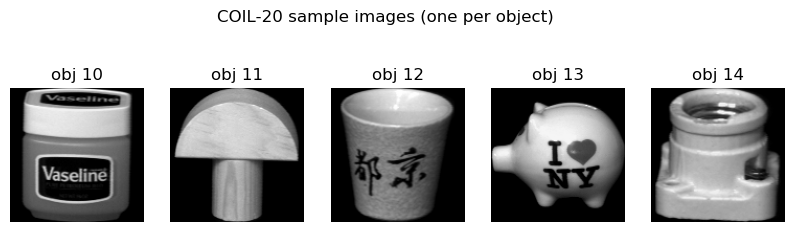

In [4]:
# Displaying some sample images from the dataset
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_coil[i * 72].reshape(128, 128), cmap='gray')
    ax.set_title('obj %d' % (y_coil[i * 72] + 1))
    ax.axis('off')
plt.suptitle('COIL-20 sample images (one per object)')
plt.show()

In [5]:
# Splitting the dataset into training and testing sets (70% train, 30% test)
X_coil_train, X_coil_test, y_coil_train, y_coil_test = train_test_split(X_coil, y_coil, test_size=0.3, random_state=42)
print('Train size:', X_coil_train.shape)
print('Test size: ', X_coil_test.shape)
print('Feature dimension (original):', X_coil_train.shape[1])

Train size: (1008, 16384)
Test size:  (432, 16384)
Feature dimension (original): 16384


**2. Johnson and Lindenstrauss Bound**

In [6]:
# Johnson-Lidenstrauss bound for COIL-20 (eps=0.1)
# For n=1440 samples, dimension d=128x128=16384 (pixels)
print('Professors Johnson and Lindenstrauss say: k >=',johnson_lindenstrauss_min_dim(len(X_coil), eps=0.1))

Professors Johnson and Lindenstrauss say: k >= 6233


**3. Getting Baseline Accuracy** 

In [7]:
model_coil=LinearSVC(random_state=42,max_iter=2000)
model_coil.fit(X_coil_train, y_coil_train)
baseline_coil=metrics.accuracy_score(y_coil_test, model_coil.predict(X_coil_test))
print('Baseline accuracy (no projection): %.4f' % baseline_coil)

Baseline accuracy (no projection): 0.9907


**4. Sparse Random Projection**

In [7]:
# Applying sparse random projection for varying dimensions
accuracies_coil = []
dims_coil = np.int32(np.linspace(2, 500, 20))
for dim in dims_coil:
    sp = SparseRandomProjection(n_components=dim, random_state=42)
    X_proj = sp.fit_transform(X_coil_train)
    model = LinearSVC(max_iter=2000)
    model.fit(X_proj, y_coil_train)
    test_proj = sp.transform(X_coil_test)
    accuracies_coil.append(metrics.accuracy_score(y_coil_test, model.predict(test_proj)))

**5. Ensembled Random Projection**

In [8]:
# Applying ensembled sparse random projection over multiple realizations
n_realizations = 25
accuracies_coil_ens = np.zeros((n_realizations, len(dims_coil)))
for j, dim in enumerate(dims_coil):
    for i in range(n_realizations):
        sp = SparseRandomProjection(n_components=dim)
        X_proj = sp.fit_transform(X_coil_train)
        model = LinearSVC(max_iter=2000)
        model.fit(X_proj, y_coil_train)
        test_proj = sp.transform(X_coil_test)
        accuracies_coil_ens[i, j] = metrics.accuracy_score(y_coil_test, model.predict(test_proj))
# Averaging across realizations
avg_accuracies_coil = accuracies_coil_ens.mean(axis=0)

**Plotting Sparse Random Projection and Ensembled Random Projection**

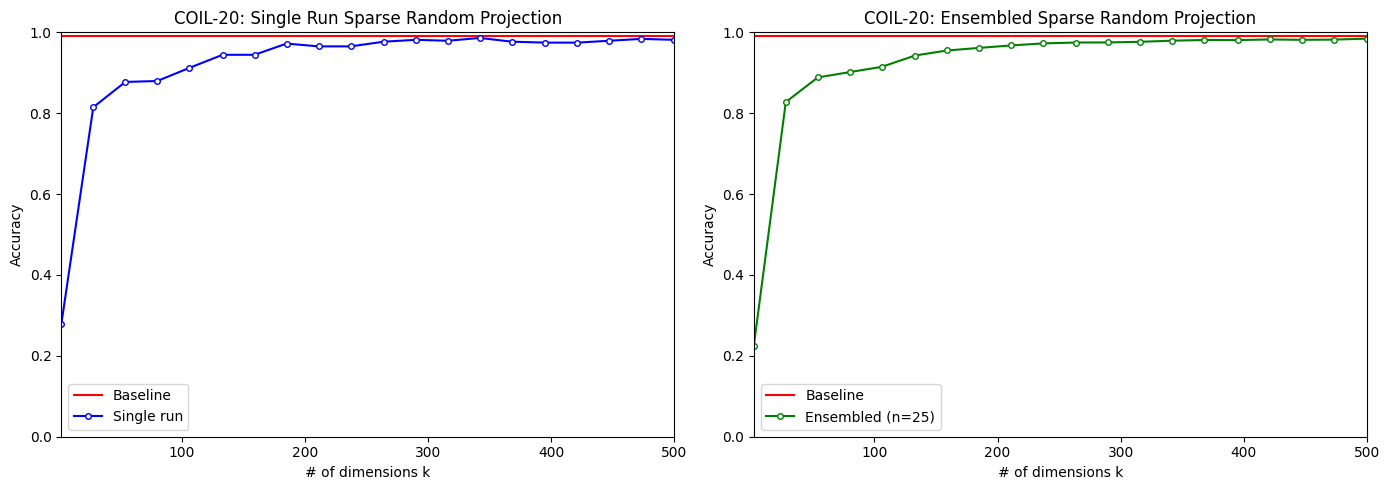

In [9]:
# Plotting single run sparse random projection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(dims_coil, [baseline_coil] * len(dims_coil), color='r', label='Baseline')
axes[0].plot(dims_coil, accuracies_coil, color='b', label='Single run',marker='o', markersize=4, markerfacecolor='white', markeredgewidth=1)
axes[0].set_xlabel('# of dimensions k')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('COIL-20: Single Run Sparse Random Projection')
axes[0].set_xlim([2, 500])
axes[0].set_ylim([0, 1])
axes[0].legend()
# Plotting ensembled sparse random projection
axes[1].plot(dims_coil, [baseline_coil] * len(dims_coil), color='r', label='Baseline')
axes[1].plot(dims_coil, avg_accuracies_coil, color='g', label='Ensembled (n=25)',marker='o', markersize=4, markerfacecolor='white', markeredgewidth=1)
axes[1].set_xlabel('# of dimensions k')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('COIL-20: Ensembled Sparse Random Projection')
axes[1].set_xlim([2, 500])
axes[1].set_ylim([0, 1])
axes[1].legend()
plt.tight_layout()
plt.show()

**Conclusion for Dataset 1**
- The baseline accuracy without any projection is `0.9907` (99.07%), computed using a LinearSVC on the full 16,384-dimensional space.
- The *single run curve* shows **slight dips and bumps (around k = 150) due to the randomness of individual projections**.
- The *ensembled curve* (25 realizations averaged) is **visibly smoother, confirming that averaging over multiple random projections removes variance caused by any single projection matrix.**
- Also, near baseline accuracy `(~99%)` is recovered at roughly `k=300-400` dimensions far below the **JL bound of `6233`**, suggesting the bound is highly conservative for this dataset.
- This result aligns with the expected behavior for image data embedded in Euclidean space: since pixel-wise Euclidean distance is a meaningful similarity measure for COIL-20, random projections preserve the structure needed for classification even at a small fraction of the original dimensionality.

#### **Dataset 2: Breast Cancer Wisconsin (Diagnostic)**

In [16]:
# Importing necessary libraries
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

**1. Loading the Dataset**

In [17]:
from sklearn.datasets import load_breast_cancer
data_bc = load_breast_cancer(as_frame=True)
df_bc= data_bc.frame  
X_bc = df_bc.drop(columns='target').values  
y_bc = df_bc['target'].values              
print('Breast Cancer shape:', X_bc.shape)
print('Number of classes:', len(np.unique(y_bc)))


Breast Cancer shape: (569, 30)
Number of classes: 2


In [18]:
print(df_bc.columns)
df_bc.sample(4)

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
197,18.08,21.84,117.40,1024.0,0.07371,0.08642,0.11030,0.05778,0.1770,0.05340,...,24.70,129.10,1228.0,0.08822,0.19630,0.2535,0.09181,0.2369,0.06558,0
198,19.18,22.49,127.50,1148.0,0.08523,0.14280,0.11140,0.06772,0.1767,0.05529,...,32.06,166.40,1688.0,0.13220,0.56010,0.3865,0.17080,0.3193,0.09221,0
192,9.72,18.22,60.73,288.1,0.06950,0.02344,0.00000,0.00000,0.1653,0.06447,...,20.83,62.25,303.8,0.07117,0.02729,0.0000,0.00000,0.1909,0.06559,1
542,14.74,25.42,94.70,668.6,0.08275,0.07214,0.04105,0.03027,0.1840,0.05680,...,32.29,107.40,826.4,0.10600,0.13760,0.1611,0.10950,0.2722,0.06956,1


In [19]:
# Train-test split (70% train, 30% test)
X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(X_bc, y_bc, test_size=0.3, random_state=42, stratify=y_bc)
print('Train size:', X_bc_train.shape)
print('Test size: ', X_bc_test.shape)
print('Feature dimension (original):', X_bc_train.shape[1])

Train size: (398, 30)
Test size:  (171, 30)
Feature dimension (original): 30


**2. Johnson and Lindenstrauss Bound**

In [20]:
# Johnson-Lindenstrauss bound for Breast Cancer (eps=0.1)
print('Professors Johnson and Lindenstrauss say: k >=',
      johnson_lindenstrauss_min_dim(len(X_bc), eps=0.1))

Professors Johnson and Lindenstrauss say: k >= 5437


Although the dataset has only 30 features, the required dimension is larger than 5437.

The required embedding dimension depends only on the number of samples (n=569). The large number occurs because the bound is a conservative worst-case guarantee for preserving all pairwise distances, and can therefore exceed the original dimensionality. In practice, much lower dimensions are often sufficient.

**3. Getting Baseline Accuracy** 

In [21]:
model_bc = LinearSVC(random_state=42, max_iter=5000)
model_bc.fit(X_bc_train, y_bc_train)
baseline_bc = metrics.accuracy_score(y_bc_test, model_bc.predict(X_bc_test))
print('Baseline accuracy (no projection): %.4f' % baseline_bc)

Baseline accuracy (no projection): 0.9474


**4. Sparse Random Projection**

In [22]:
accuracies_bc = []
dims_bc = np.int32(np.linspace(2, 30, 15))
for dim in dims_bc:
    sp = SparseRandomProjection(n_components=dim, random_state=42)
    X_proj = sp.fit_transform(X_bc_train)
    model = LinearSVC(max_iter=5000)
    model.fit(X_proj, y_bc_train)
    test_proj = sp.transform(X_bc_test)
    accuracies_bc.append(metrics.accuracy_score(y_bc_test, model.predict(test_proj)))

**5. Ensembled Random Projection**

In [23]:
n_realizations = 25
accuracies_bc_ens = np.zeros((n_realizations, len(dims_bc)))
for j, dim in enumerate(dims_bc):
    for i in range(n_realizations):
        sp = SparseRandomProjection(n_components=dim, random_state=42 + i)
        X_proj = sp.fit_transform(X_bc_train)
        model = LinearSVC(max_iter=5000)
        model.fit(X_proj, y_bc_train)
        test_proj = sp.transform(X_bc_test)
        accuracies_bc_ens[i, j] = metrics.accuracy_score(
            y_bc_test, model.predict(test_proj)
        )
avg_accuracies_bc = accuracies_bc_ens.mean(axis=0)

**Plotting Sparse Random Projection and Ensembled Random Projection**

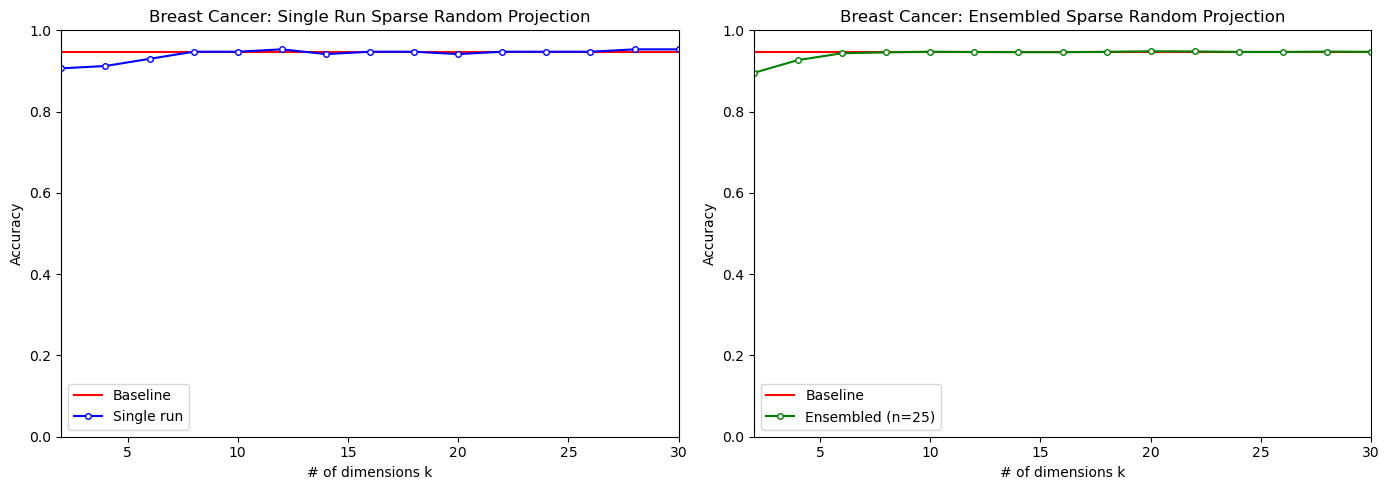

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plotting single run sparse random projection
axes[0].plot(dims_bc, [baseline_bc] * len(dims_bc), color='r', label='Baseline')
axes[0].plot(dims_bc, accuracies_bc, color='b', label='Single run',
             marker='o', markersize=4, markerfacecolor='white', markeredgewidth=1)
axes[0].set_xlabel('# of dimensions k')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Breast Cancer: Single Run Sparse Random Projection')
axes[0].set_xlim([2, 30])
axes[0].set_ylim([0, 1])
axes[0].legend()
# Plotting ensembled sparse random projection
axes[1].plot(dims_bc, [baseline_bc] * len(dims_bc), color='r', label='Baseline')
axes[1].plot(dims_bc, avg_accuracies_bc, color='g', label='Ensembled (n=25)',
             marker='o', markersize=4, markerfacecolor='white', markeredgewidth=1)
axes[1].set_xlabel('# of dimensions k')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Breast Cancer: Ensembled Sparse Random Projection')
axes[1].set_xlim([2, 30])
axes[1].set_ylim([0, 1])
axes[1].legend()

plt.tight_layout()
plt.show()

**Conclusion for Dataset 2**
- The baseline accuracy without any projection is `0.9474` (94.74%), computed using a LinearSVC on the original 30-dimensional feature space.
- The *single run curve* shows **small fluctuations across different values of k.**. These variations are expected, as each random projection uses a different random matrix, which can slightly distort distances and affect classification performance.
- The *ensembled curve* (25 realizations averaged) is **visibly smoother**, again confirming that averaging over multiple random projections removes variance caused by any single projection matrix.
- Also, high accuracy is preserved even at relatively low dimensions (e.g., k≈5–10), indicating that the dataset has a **low intrinsic dimensionality** and does not require all 30 original features to achieve strong performance.

**6. Comparing COIL-20 and Breast Cancer Wisconsin Datasets**

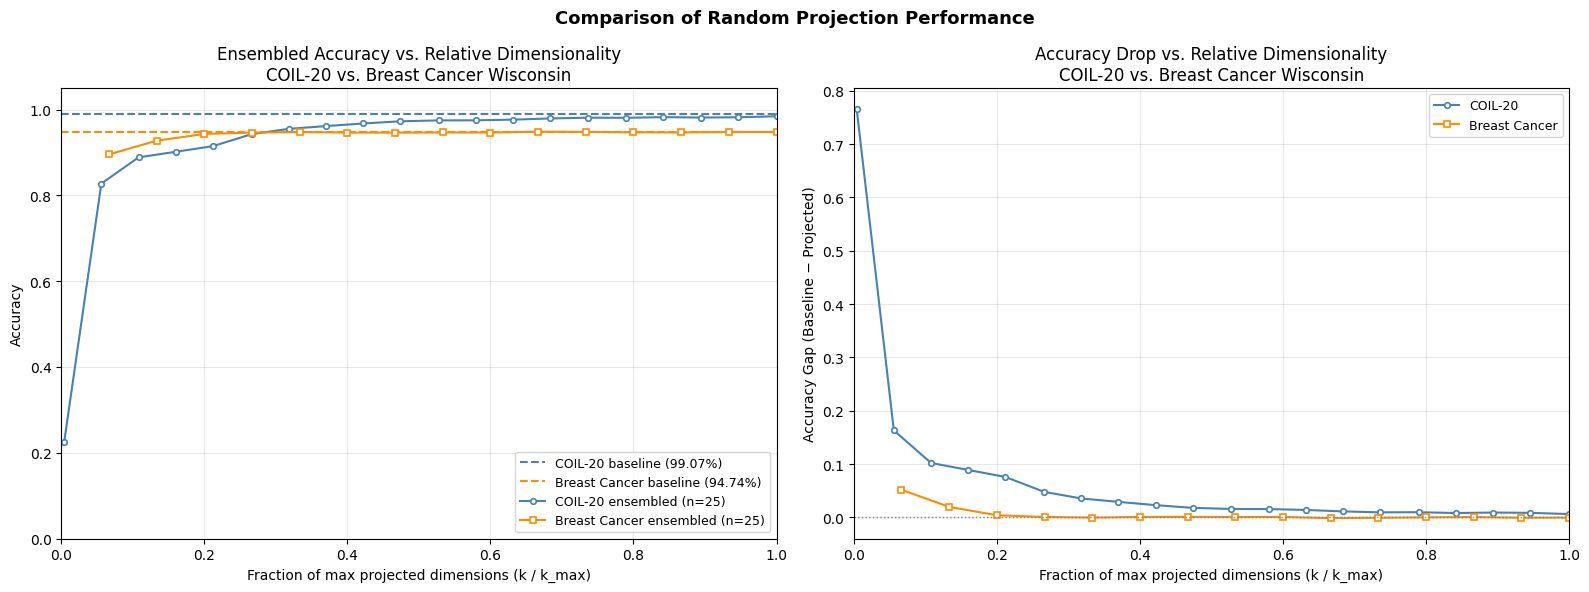


----------------------------------------------------------------------
Dataset                          Baseline  Best projected  k_max
----------------------------------------------------------------------
COIL-20                            99.07%          98.44%    500
Breast Cancer Wisconsin            94.74%          94.85%     30
----------------------------------------------------------------------


In [19]:
# Normalising x-axis to [0, 1] for comparison
x_coil_norm = dims_coil / dims_coil.max()      
x_bc_norm   = dims_bc   / dims_bc.max()          
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Left panel: Ensembled accuracy curves (both datasets) 
axes[0].axhline(baseline_coil, color='steelblue',  linestyle='--', linewidth=1.5,
                label=f'COIL-20 baseline ({baseline_coil:.2%})')
axes[0].axhline(baseline_bc,   color='darkorange', linestyle='--', linewidth=1.5,
                label=f'Breast Cancer baseline ({baseline_bc:.2%})')
axes[0].plot(x_coil_norm, avg_accuracies_coil,
             color='steelblue',  marker='o', markersize=4,
             markerfacecolor='white', markeredgewidth=1.2,
             label='COIL-20 ensembled (n=25)')
axes[0].plot(x_bc_norm, avg_accuracies_bc,
             color='darkorange', marker='s', markersize=4,
             markerfacecolor='white', markeredgewidth=1.2,
             label='Breast Cancer ensembled (n=25)')
axes[0].set_xlabel('Fraction of max projected dimensions (k / k_max)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Ensembled Accuracy vs. Relative Dimensionality\nCOIL-20 vs. Breast Cancer Wisconsin')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(alpha=0.3)

# Right panel: Accuracy gap to baseline 
gap_coil = baseline_coil - avg_accuracies_coil
gap_bc   = baseline_bc   - avg_accuracies_bc
axes[1].plot(x_coil_norm, gap_coil,
             color='steelblue',  marker='o', markersize=4,
             markerfacecolor='white', markeredgewidth=1.2,
             label='COIL-20')
axes[1].plot(x_bc_norm, gap_bc,
             color='darkorange', marker='s', markersize=4,
             markerfacecolor='white', markeredgewidth=1.2,
             label='Breast Cancer')
axes[1].axhline(0, color='grey', linestyle=':', linewidth=1)
axes[1].set_xlabel('Fraction of max projected dimensions (k / k_max)')
axes[1].set_ylabel('Accuracy Gap (Baseline − Projected)')
axes[1].set_title('Accuracy Drop vs. Relative Dimensionality\nCOIL-20 vs. Breast Cancer Wisconsin')
axes[1].set_xlim([0, 1])
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(alpha=0.3)
plt.suptitle('Comparison of Random Projection Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
# Summary table 
print(f"\n{'-'*70}")
print(f"{'Dataset':<30} {'Baseline':>10} {'Best projected':>15} {'k_max':>6}")
print(f"{'-'*70}")
print(f"{'COIL-20':<30} {baseline_coil:>10.2%} {avg_accuracies_coil.max():>15.2%} {dims_coil.max():>6d}")
print(f"{'Breast Cancer Wisconsin':<30} {baseline_bc:>10.2%} {avg_accuracies_bc.max():>15.2%} {dims_bc.max():>6d}")
print(f"{'-'*70}")


##### **7. Conclusion**

**Comparison**

| | COIL-20 | Breast Cancer |
|---|---|---|
| Original dimensionality | 16,384 | 30 |
| Baseline accuracy | 99.07% | 94.74% |
| Best projected accuracy | ~99% | ~95% |
| Dimensions needed to recover baseline | ~300–400 | ~5–10 |
| Smoothness of ensembled curve | High | High |


**Final Comparative Findings**

- The comparison highlights how random projection behaves differently depending on the dimensionality and geometric structure of the dataset.

- For COIL-20, a high-dimensional image dataset, random projection achieves over 97% dimensionality reduction with almost no loss in accuracy, confirming that the data lies on a low-dimensional manifold where Euclidean distances are meaningful and well-preserved under projection.

- For the Breast Cancer dataset, the accuracy curve remains nearly flat and very close to baseline across almost all values of k, recovering baseline performance at around k = 5-10 dimensions out of 30. This shows that even in a low-dimensional tabular setting, random projection effectively preserves the discriminative structure of the data.

- These results demonstrate that random projection is most effective for high-dimensional data with underlying geometric structure, and less suitable for low-dimensional tabular data.

**Take-Home Message**

- Random projection is most effective when the data lies in a high-dimensional space with a low intrinsic dimensionality and when Euclidean distances meaningfully capture similarity.

- Its practical benefit depends less on the nominal dimensionality and more on the underlying geometric structure of the data.

- While random projections can preserve classification performance across different settings, the achievable dimensionality reduction is substantial only when significant redundancy exists in the feature space.

- Finally, averaging over multiple random projections is essential for reducing variance and obtaining stable performance estimates.
